# 09_figures.ipynb
### Purpose: Generate all figures for the manuscript.
### Figures produced: Fig 2, Fig 3, S1 Fig, S2 Fig, S3 Fig, S4 Fig.
### Author: Sara Neven
### Date: 2025

In [295]:
import os
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
import seaborn as sns
import scipy.stats as stats
from statsmodels.stats.proportion import proportion_confint

In [296]:
colors_figures = {
    "Lighter Teal":   "#4DB6AC",   # Brown Chromis species, attack speed (Fig 2)
    "Deep Sea Blue":  "#003366",   # significant effect (S2)
    "Sky Blue":       "#87CEEB",   # sub-threshold stimulus (Fig 2B)
    "Coral":          "#FF7F50",   # fraction of responses (all figs), supra-threshold stimulus (Fig 2B)
    "Seafoam Blue":   "#78D1B6",   # neighbor proximity (S1D)
    "Sunshine Red":   "#FF4500",   # median / reference lines
    "Off-White":      "#F8F8F8",
    "Ocean Foam":     "#7FFFD4",
    "Midnight Blue":  "#191970",
    "Black":          "#000000",
    "Sunshine Yellow":"#FFD700",   # cruising speed (Fig 2B)
    "Soft Magenta":   "#C276B1",
    "Ocean Blue":     "#0072B2",   # Bicolor Damselfish species
    "Neutral Gray":   "#999999",   # not significant effect (S2)
}

# ── PLOS ONE column widths (inches) ─────────────────────────────────────────
W_SINGLE = 3.27   # 83 mm  – single-column figure
W_ONEANDHALF = 4.96   # 126 mm – 1.5-column figure
W_DOUBLE = 6.69   # 170 mm – double-column figure (maximum)
H_MAX    = 9.61   # 244 mm – maximum figure height

# ── Shared layout margins ────────────────────────────────────────────────────
FIG_LEFT   = 0.12
FIG_RIGHT  = 0.97
FIG_TOP    = 0.95
FIG_BOTTOM = 0.12

# ── Panel label position (axes-relative) ────────────────────────────────────
LABEL_X = -0.12
LABEL_Y = 1.04


def set_style(base_fontsize=10):
    """Apply a PLOS ONE-compatible matplotlib style.

    Call once at the top of the notebook, or again per figure to change
    the base font size.

    Parameters
    ----------
    base_fontsize : int
        Base font size in points.  PLOS ONE minimum is 8 pt after
        any figure reduction, so keep this ≥ 9 for safety.
    """
    mpl.rcParams.update({
        # ── Fonts ───────────────────────────────────────────────────────────
        "font.family":           "sans-serif",
        "font.sans-serif":       ["Arial", "Helvetica", "DejaVu Sans"],
        "font.size":             base_fontsize,
        "axes.titlesize":        base_fontsize,
        "axes.labelsize":        base_fontsize,
        "xtick.labelsize":       base_fontsize - 1,
        "ytick.labelsize":       base_fontsize - 1,
        "legend.fontsize":       base_fontsize - 1,
        "legend.title_fontsize": base_fontsize,

        # ── Mathtext (keeps Arial in labels like "m s$^{-1}$") ─────────────
        "mathtext.default": "regular",
        "mathtext.fontset": "custom",
        "mathtext.rm":      "Arial",
        "mathtext.it":      "Arial:italic",
        "mathtext.bf":      "Arial:bold",

        # ── Lines & markers ─────────────────────────────────────────────────
        "lines.linewidth": 1.5,
        "lines.markersize": 5,

        # ── Axes ─────────────────────────────────────────────────────────────
        "axes.linewidth":    0.8,
        "axes.spines.top":   False,
        "axes.spines.right": False,
        "axes.grid":         True,
        "grid.linestyle":    ":",
        "grid.alpha":        0.2,
        "grid.linewidth":    0.8,

        # ── Colors ───────────────────────────────────────────────────────────
        "axes.facecolor":    "white",
        "figure.facecolor":  "white",
        "savefig.facecolor": "white",

        # ── Legend ───────────────────────────────────────────────────────────
        "legend.frameon":        False,
        "legend.borderpad":      0.3,
        "legend.labelspacing":   0.3,
        "legend.handletextpad":  0.4,

        # ── PDF / PS font embedding (Type-1 / TrueType, editable) ───────────
        "pdf.fonttype": 42,
        "ps.fonttype":  42,
    })


def add_panel_label(ax, label, x=LABEL_X, y=LABEL_Y):
    """Place a bold panel label outside the axes, top-left corner."""
    ax.text(x, y, label,
            transform=ax.transAxes,
            fontsize=mpl.rcParams['font.size'] + 1,
            fontweight='bold',
            va='top', ha='left',
            clip_on=False)


set_style(base_fontsize=11)  # apply once; call again per figure to change base_fontsize

In [297]:
figures_dir = '../outputs/figures'
os.makedirs(figures_dir, exist_ok=True)

dataframe_stimulus = pd.read_csv('../data/filtered_observations.csv')
dataframe_real     = pd.read_csv('../data/predator_attack_speeds.csv')

## Precompute shared bin statistics

Bin statistics for distance to stimulus, viewing angle, and distance to coral are reused across multiple figures.

In [298]:
z = stats.norm.ppf(0.975)

def bin_stats(df, col, n_bins=8, min_count=15):
    """Compute binned response fractions with 95% CI."""
    bins = np.linspace(df[col].min(), df[col].max(), n_bins)
    df = df.copy()
    df['_bin'] = pd.cut(df[col], bins=bins)
    grouped = df.groupby('_bin', observed=True)['Response_Binary']
    means  = grouped.mean()
    counts = grouped.count()
    centers = np.array([iv.mid for iv in means.index])
    ci_hw   = z * np.sqrt(means * (1 - means) / counts)
    valid   = counts >= min_count
    return {
        'centers':  centers[valid],
        'means':    means[valid],
        'ci_lower': np.clip(means - ci_hw, 0, 1)[valid],
        'ci_upper': np.clip(means + ci_hw, 0, 1)[valid],
    }

# Distance to stimulus (convert mm -> m)
dataframe_stimulus['Distance_to_Stimulus_m'] = dataframe_stimulus['Distance_to_Stimulus'] / 1000
stats_dst = bin_stats(dataframe_stimulus, 'Distance_to_Stimulus_m')

# Viewing angle
stats_va = bin_stats(dataframe_stimulus, 'Viewing_Angle')

# Distance to coral (convert mm -> m)
dataframe_stimulus['Distance_to_Coral_m'] = dataframe_stimulus['Distance_to_Coral'] / 1000
stats_dco = bin_stats(dataframe_stimulus, 'Distance_to_Coral_m')

# Orientation angle and trial event (for S4 Fig)
stats_oa  = bin_stats(dataframe_stimulus, 'Orientation_Angle')
stats_tev = bin_stats(dataframe_stimulus, 'Trial_Event')

## Figure 2: Stimulus speed response and predator attack speeds

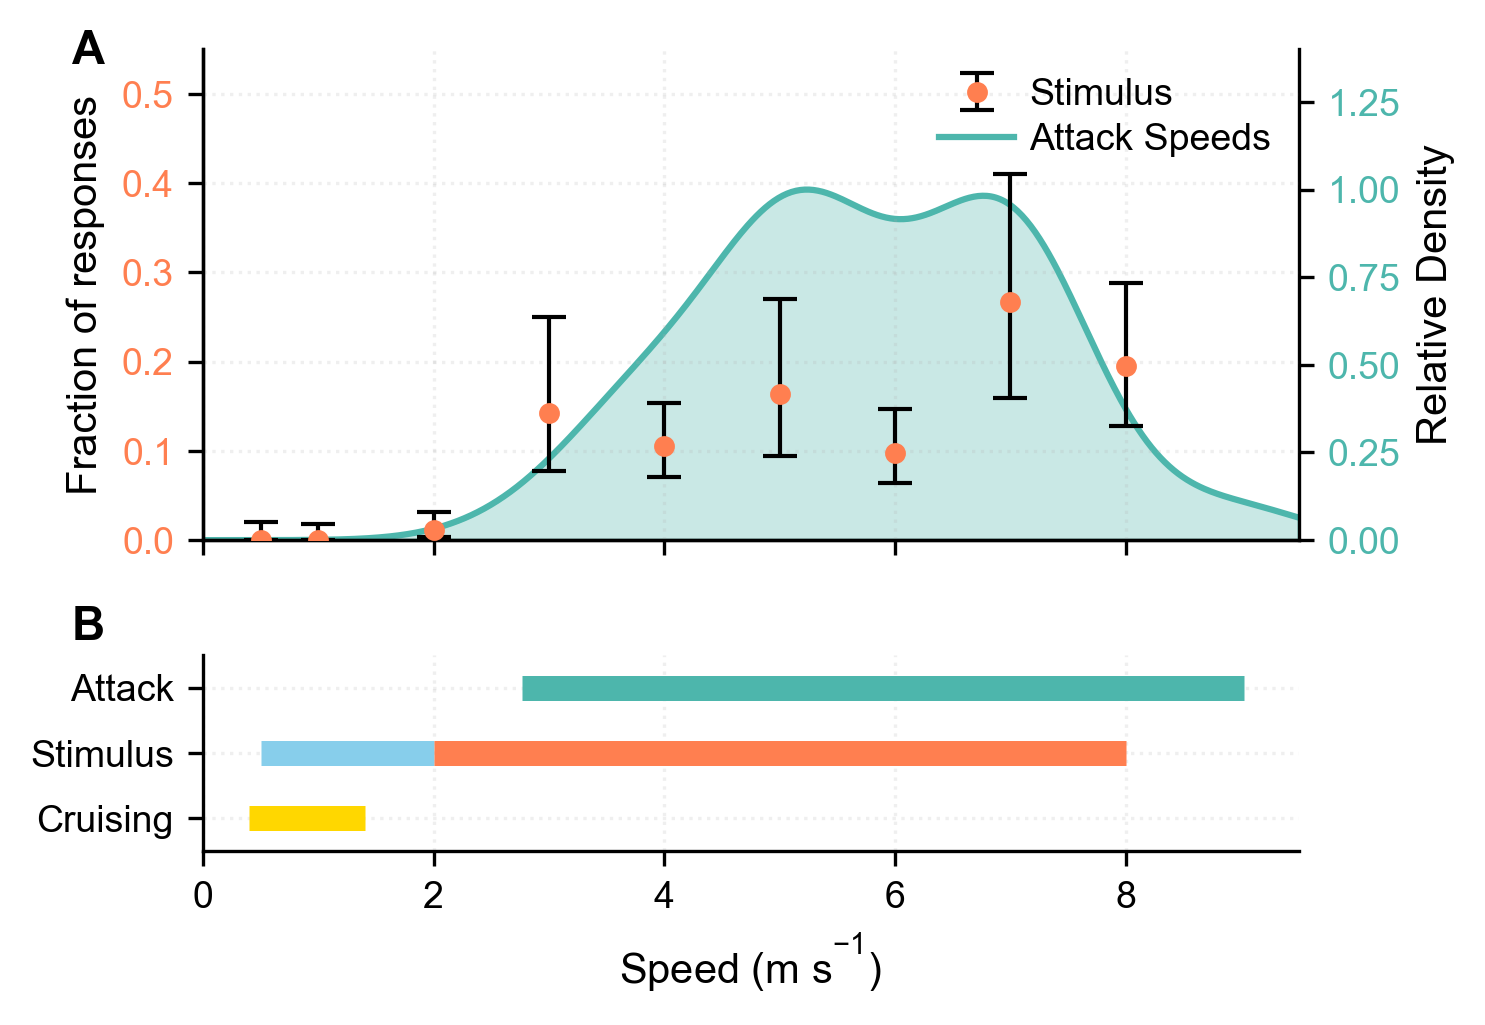

In [310]:
def plot_fig2(dataframe_stimulus, dataframe_real, loom_speeds, figures_dir, colors_figures):
    set_style(base_fontsize=10)
    fig, ax = plt.subplots(
        nrows=2, ncols=1, figsize=(W_ONEANDHALF, 3.5), dpi=300,
        sharex=True, gridspec_kw={'height_ratios': [2, 0.8]}
    )

    # Panel A: response fraction per stimulus speed

    bin_edges = np.append([loom_speeds[0] - 0.25], loom_speeds + 0.25)
    dataframe_stimulus = dataframe_stimulus.copy()
    dataframe_stimulus['Binned_Speed'] = pd.cut(
        dataframe_stimulus['Loom_Speed'], bins=bin_edges, labels=loom_speeds
    )

    grouped = dataframe_stimulus.groupby('Binned_Speed', observed=True)['Response_Binary']
    n_yes   = grouped.apply(lambda x: (x == 1).sum()).reindex(loom_speeds, fill_value=0)
    n_total = grouped.size().reindex(loom_speeds, fill_value=0)
    prop    = n_yes / n_total.replace(0, np.nan)

    lower, upper = proportion_confint(n_yes, n_total, alpha=0.05, method='wilson')
    lower = np.nan_to_num(lower)
    upper = np.nan_to_num(upper)

    ax[0].set_ylim(0, 0.55)
    ax[0].set_ylabel('Fraction of responses')
    ax[0].tick_params(labelcolor=colors_figures['Coral'])

    # Right axis: predator attack speed density
    ax2 = ax[0].twinx()
    ax2.grid(False)
    ax2.spines['right'].set_visible(True)
    ax[0].set_zorder(10)
    ax[0].patch.set_visible(False)
    real_speeds = dataframe_real['P90_Speed'].dropna()
    kde = stats.gaussian_kde(real_speeds, bw_method=0.45)
    x_grid = np.linspace(loom_speeds[0] - 0.5, 9.5, 500)
    pdf_vals = kde(x_grid)
    pdf_vals /= pdf_vals.max()

    ax2.fill_between(x_grid, 0, pdf_vals, color=colors_figures['Lighter Teal'], alpha=0.3, zorder=1)
    ax2.plot(x_grid, pdf_vals, color=colors_figures['Lighter Teal'], linewidth=1.5,
             label='Attack Speeds', zorder=2)
    ax2.set_xlim(loom_speeds[0] - 0.5, 9.5)
    ax[0].set_xlim(loom_speeds[0] - 0.5, 9.5)
    ax2.set_ylim(0, 1.4)
    ax2.set_ylabel('Relative Density')
    ax2.tick_params(labelcolor=colors_figures['Lighter Teal'])

    ax[0].errorbar(
        loom_speeds, prop, yerr=[prop - lower, upper - prop],
        fmt='o', markersize=4, linewidth=1,
        color=colors_figures['Coral'], ecolor=colors_figures['Black'],
        capsize=4, label='Stimulus', zorder=3
    )

    lines, labels   = ax[0].get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax[0].legend(lines + lines2, labels + labels2,
                 loc='upper right', bbox_to_anchor=(0.985, 0.965),
                 frameon=False, borderaxespad=0.0)

    # Panel B: speed range bars
    ax[1].set_ylim(0.5, 3.5)
    ax[1].set_yticks([1, 2, 3])
    ax[1].set_yticklabels(['Cruising', 'Stimulus', 'Attack'])
    ax[1].set_xlabel(r'Speed (m s$^{-1}$)')

    ax[1].hlines(1, 0.4, 1.4, colors=colors_figures['Sunshine Yellow'], linewidth=6)
    ax[1].hlines(2, 0.5, 2.0, colors=colors_figures['Sky Blue'],        linewidth=6)
    ax[1].hlines(2, 2.0, 8.0, colors=colors_figures['Coral'],           linewidth=6)
    ax[1].hlines(3, dataframe_real['P90_Speed'].min(),
                    dataframe_real['P90_Speed'].max(),
                    colors=colors_figures['Lighter Teal'], linewidth=6)

    add_panel_label(ax[0], 'A')
    add_panel_label(ax[1], 'B', y=1.25)

    plt.tight_layout(pad=1.0)
    plt.savefig(f'{figures_dir}/Figure2.tiff', format='tiff', dpi=300, bbox_inches='tight',
                pil_kwargs={'compression': 'tiff_lzw'})
    plt.savefig(f'{figures_dir}/Figure2.pdf', bbox_inches='tight')
    plt.savefig(f'{figures_dir}/Figure2.png', dpi=300, bbox_inches='tight')
    plt.show()


loom_speeds = np.array([0.5, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0])
plot_fig2(dataframe_stimulus, dataframe_real, loom_speeds, figures_dir, colors_figures)

## Figure 3: Species differences linked to distance from coral refuge

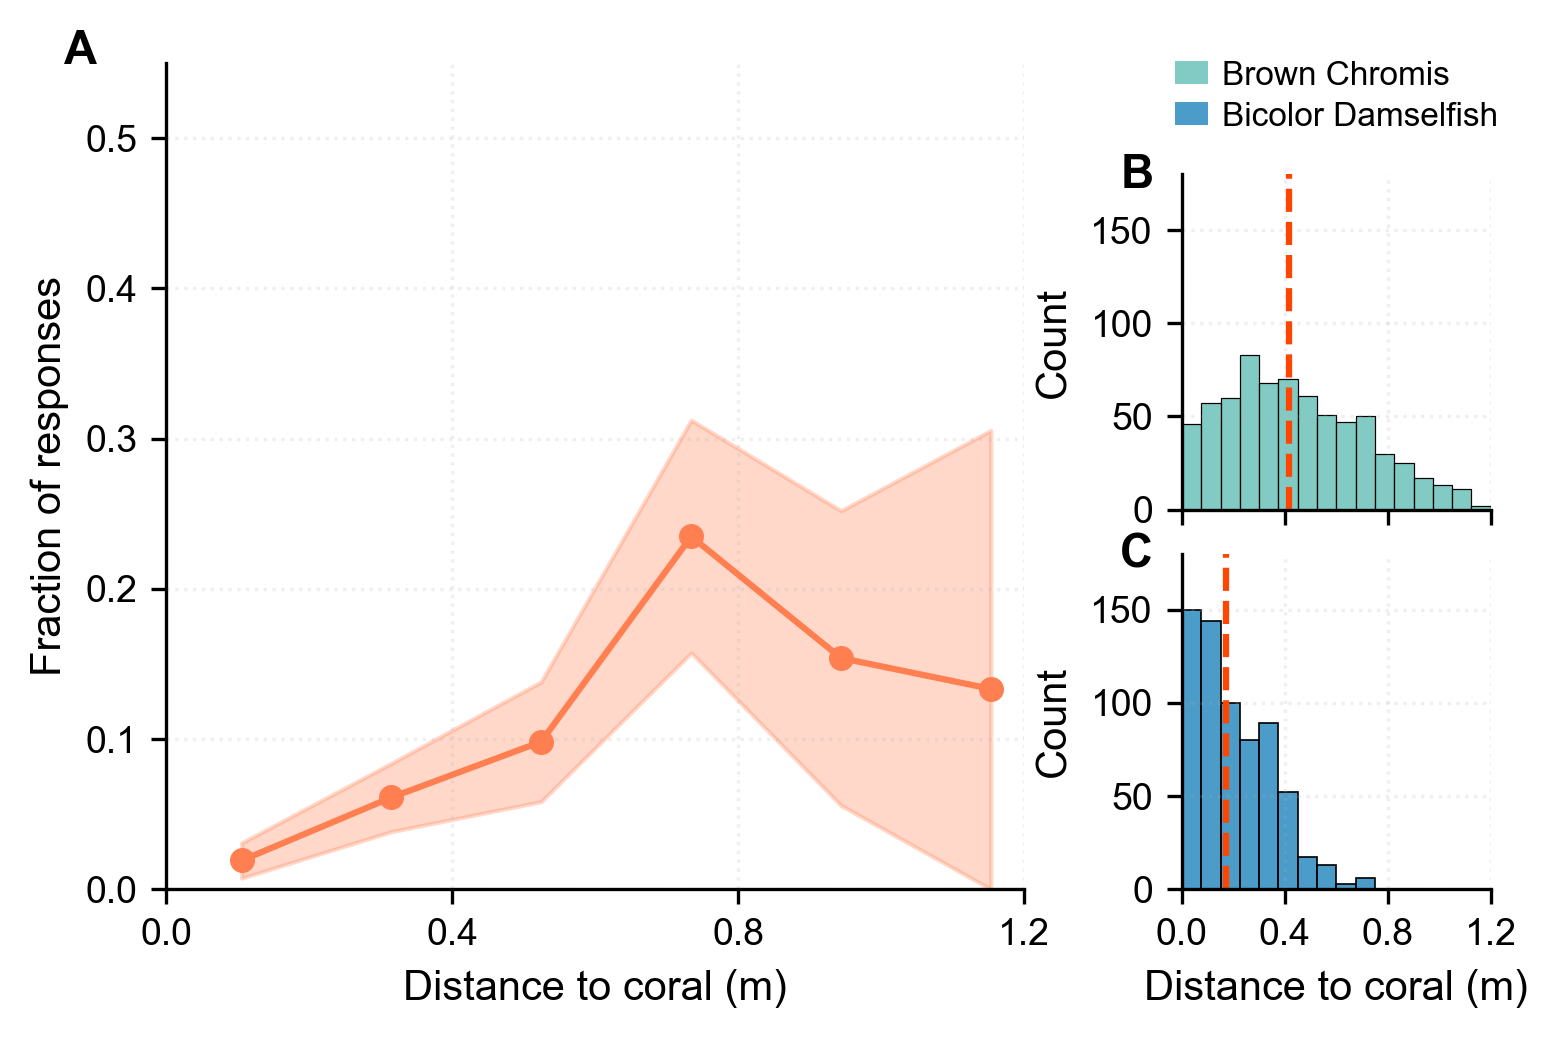

In [313]:
brown   = dataframe_stimulus[dataframe_stimulus['Species'] == 'BrownChromis']
bicolor = dataframe_stimulus[dataframe_stimulus['Species'] == 'BicolorDamselfish']

fig = plt.figure(figsize=(W_ONEANDHALF, 3.4), dpi=300)
gs  = fig.add_gridspec(3, 2,
                        width_ratios=[2.5, 0.9],
                        height_ratios=[0.2, 1, 1],   # legend | B | C
                        wspace=0.27, hspace=0.18)

# Panel A: spans ALL 3 rows on the left
ax_main = fig.add_subplot(gs[:, 0])
ax_main.plot(stats_dco['centers'], stats_dco['means'],
             marker='o', color=colors_figures['Coral'])
ax_main.fill_between(stats_dco['centers'], stats_dco['ci_lower'], stats_dco['ci_upper'],
                     color=colors_figures['Coral'], alpha=0.3)
ax_main.set_xlabel('Distance to coral (m)')
ax_main.set_ylabel('Fraction of responses')
ax_main.set_xlim(0, 1.2)
ax_main.set_xticks([0, 0.4, 0.8, 1.2])
ax_main.set_ylim(0, 0.55)
add_panel_label(ax_main, 'A')

shared_bins = np.linspace(0, 1.5, 21)

legend_elements = [
    Patch(facecolor=colors_figures['Lighter Teal'], alpha=0.7, label='Brown Chromis'),
    Patch(facecolor=colors_figures['Ocean Blue'],   alpha=0.7, label='Bicolor Damselfish'),
]

# Legend: thin strip at TOP of right column — clearly above B and C
ax_leg = fig.add_subplot(gs[0, 1])
ax_leg.axis('off')
ax_leg.legend(handles=legend_elements, loc='center', frameon=False, fontsize=8, ncol=1,
              handlelength=1.0, handletextpad=0.4)

# Panel B: Brown Chromis
ax_brown = fig.add_subplot(gs[1, 1])
sns.histplot(brown['Distance_to_Coral'] / 1000, bins=shared_bins,
             ax=ax_brown, color=colors_figures['Lighter Teal'], alpha=0.7)
brown_median = (brown['Distance_to_Coral'] / 1000).median()
ax_brown.axvline(brown_median, linestyle='--',
                 color=colors_figures['Sunshine Red'], linewidth=1.5)
ax_brown.set_ylabel('Count')
ax_brown.set_xlabel('')
ax_brown.set_xlim(0, 1.2)
ax_brown.set_ylim(0, 180)
add_panel_label(ax_brown, 'B', y=1.06, x=-0.2)

# Panel C: Bicolor Damselfish
ax_bicolor = fig.add_subplot(gs[2, 1], sharex=ax_brown)
sns.histplot(bicolor['Distance_to_Coral'] / 1000, bins=shared_bins,
             ax=ax_bicolor, color=colors_figures['Ocean Blue'], alpha=0.7)
bicolor_median = (bicolor['Distance_to_Coral'] / 1000).median()
ax_bicolor.axvline(bicolor_median, linestyle='--',
                   color=colors_figures['Sunshine Red'], linewidth=1.5)
ax_bicolor.set_ylabel('Count')
ax_bicolor.set_xlabel('Distance to coral (m)')
ax_bicolor.set_xlim(0, 1.2)
ax_bicolor.set_xticks([0, 0.4, 0.8, 1.2])
ax_bicolor.set_ylim(0, 180)
add_panel_label(ax_bicolor, 'C', y=1.06, x=-0.2)

ax_brown.tick_params(bottom=True, labelbottom=False)
fig.subplots_adjust(left=0.09, right=0.98, top=0.92, bottom=0.11, wspace=0.20, hspace=0.15)
plt.savefig(f'{figures_dir}/Figure3.pdf', bbox_inches='tight')
plt.savefig(f'{figures_dir}/Figure3.tiff', dpi=300, format='tiff', bbox_inches='tight',
            pil_kwargs={'compression': 'tiff_lzw'})
plt.savefig(f'{figures_dir}/Figure3.png', dpi=300, bbox_inches='tight')
plt.show()

## S1 Fig: Variation between trial sessions

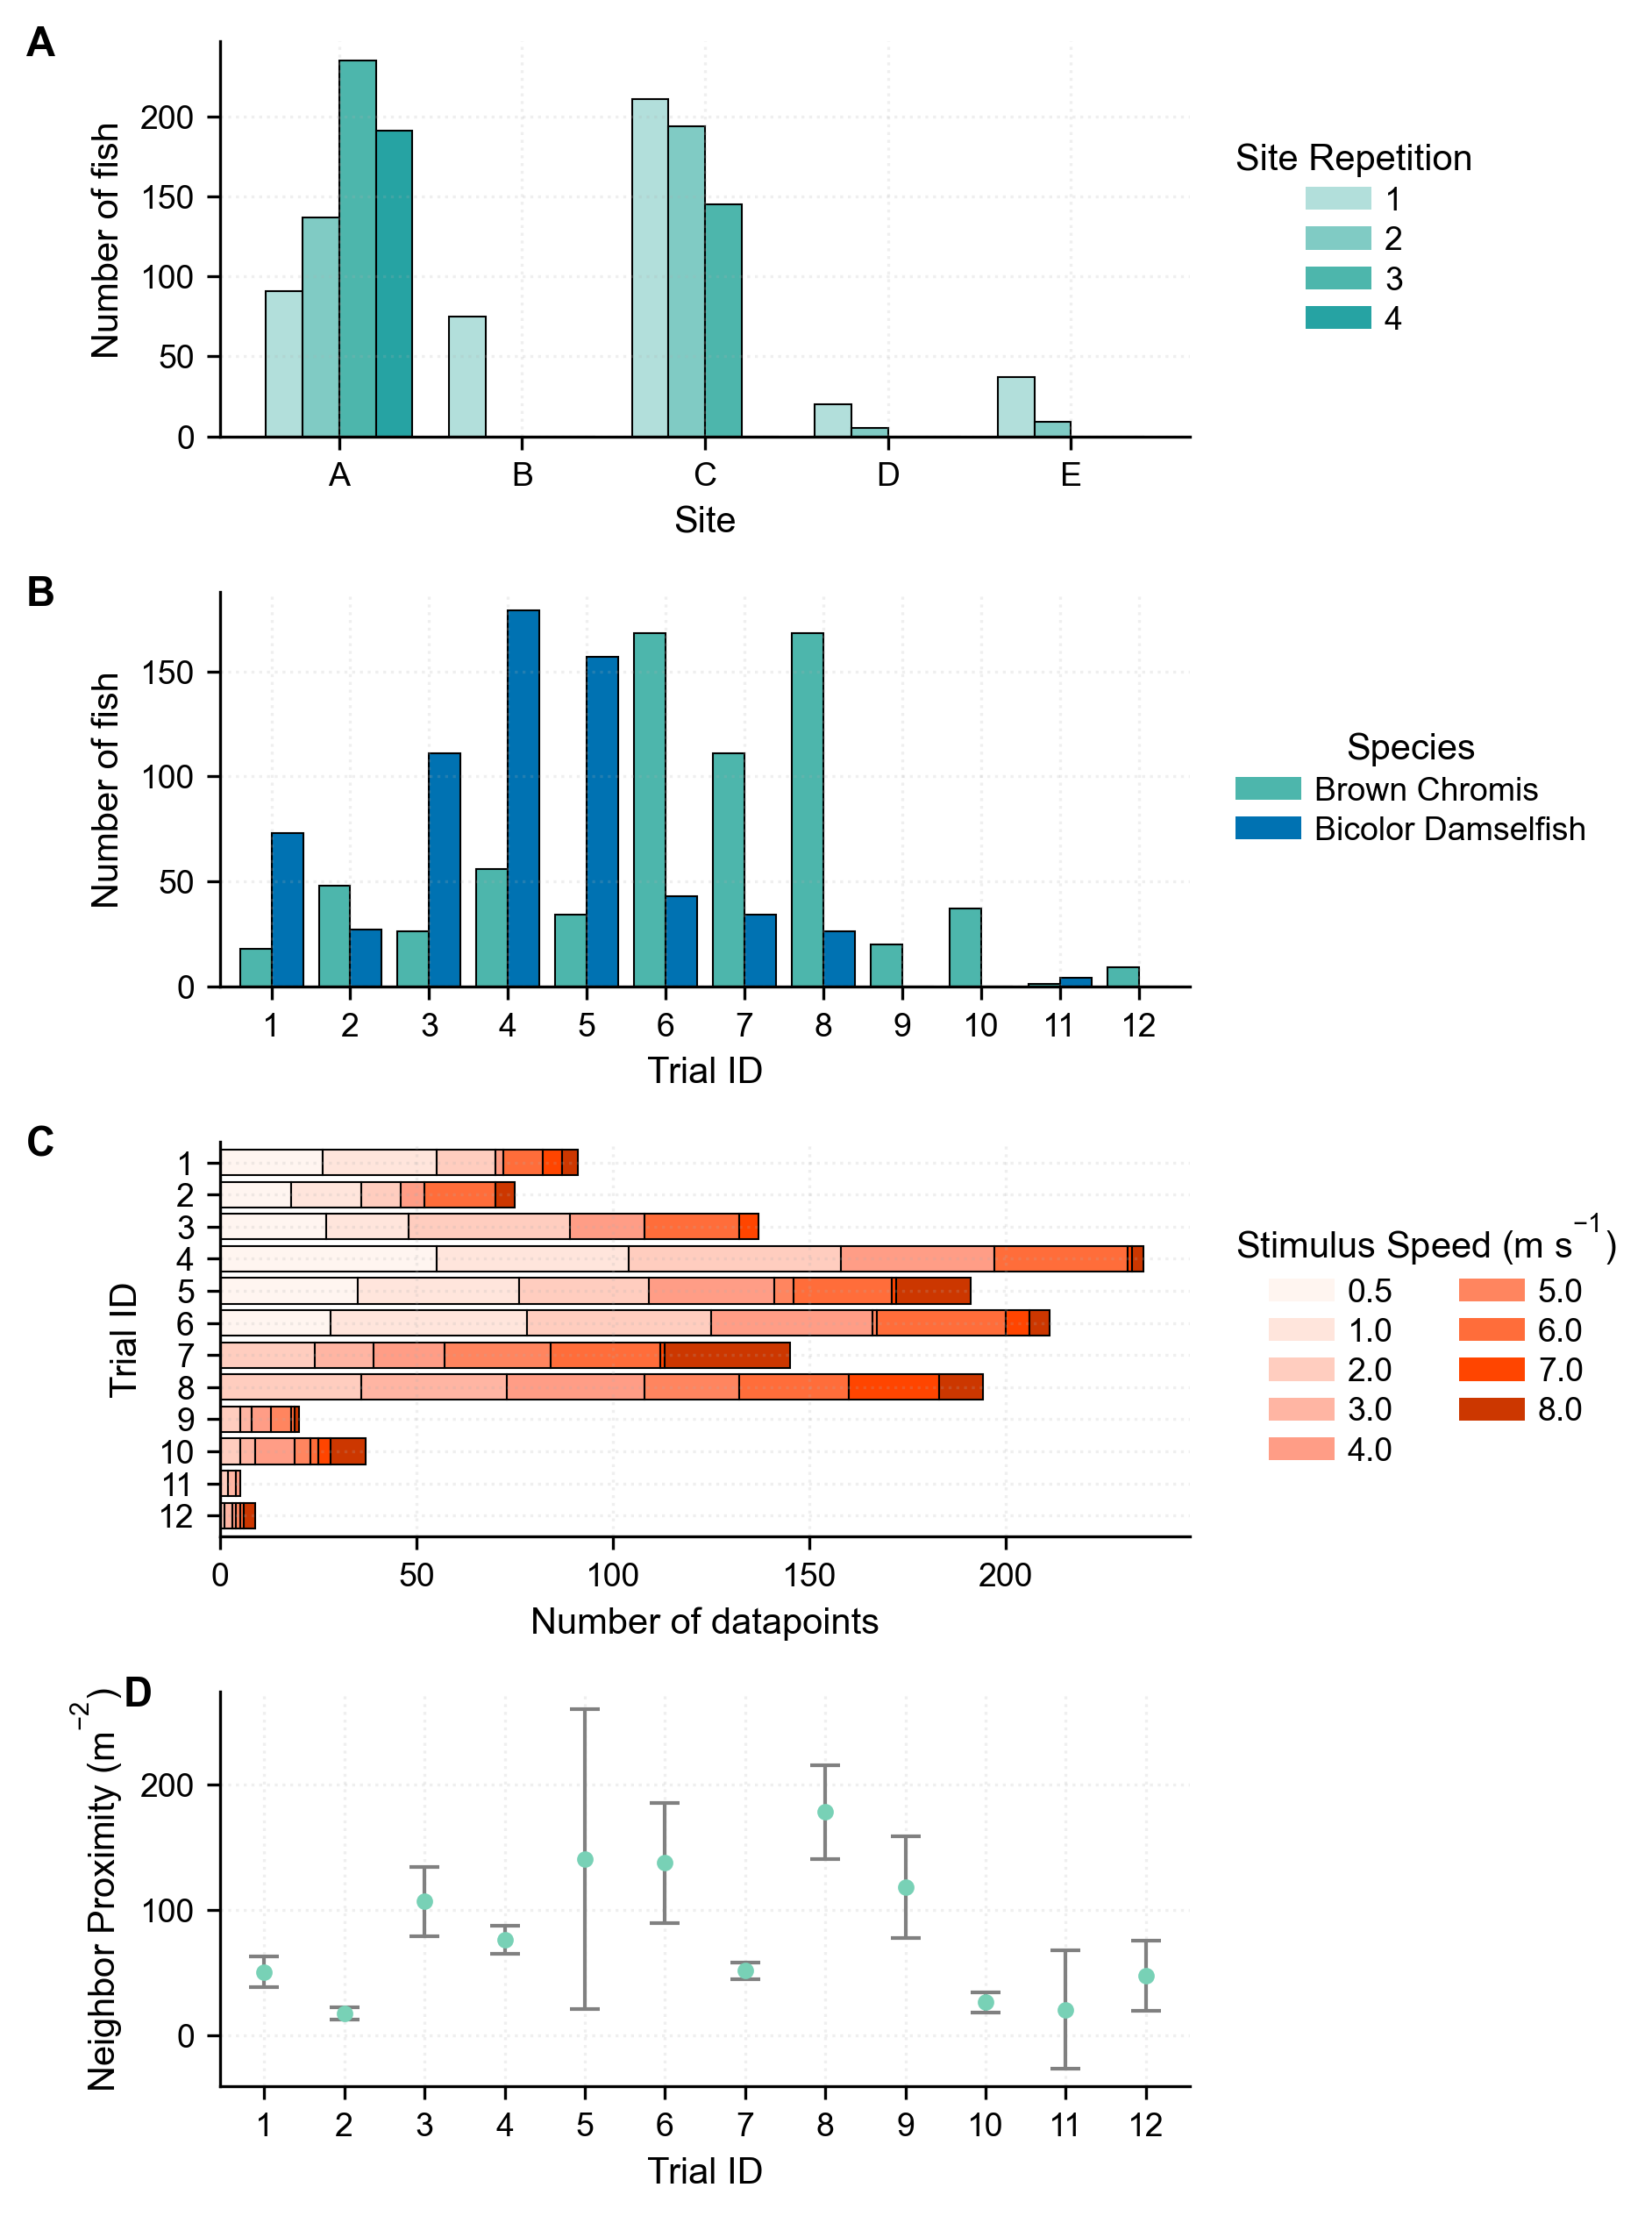

In [301]:
fig, ax = plt.subplots(4, 1, figsize=(W_DOUBLE, 8.5), dpi=300)

# Panel A: number of fish per site repetition
colors_left = ['#B2DFDB', '#80CBC4', '#4DB6AC', '#26a3a3']
fish_counts = (dataframe_stimulus
               .groupby(['Site', 'Site_Rep']).size()
               .reset_index(name='Fish_Count')
               .pivot(index='Site', columns='Site_Rep', values='Fish_Count')
               .fillna(0))
legend_A = [Patch(facecolor=c, edgecolor='none', label=str(r))
            for c, r in zip(colors_left, fish_counts.columns)]
fish_counts.plot(kind='bar', ax=ax[0], width=0.8, edgecolor='black',
                 linewidth=0.5, color=colors_left)
ax[0].set_ylabel('Number of fish')
ax[0].set_xlabel('Site')
ax[0].set_xticklabels(['A', 'B', 'C', 'D', 'E'], rotation=0)
ax[0].legend(handles=legend_A, title='Site Repetition',
             frameon=False, loc='center left', bbox_to_anchor=(1.02, 0.5))
add_panel_label(ax[0], 'A', x=-0.2)

# Panel B: species composition per trial — Brown Chromis first, consistent colors
name_map = {'BicolorDamselfish': 'Bicolor Damselfish', 'BrownChromis': 'Brown Chromis'}
sp_counts = (dataframe_stimulus
             .groupby(['Dep_ID', 'Species']).size()
             .reset_index(name='Count')
             .pivot(index='Dep_ID', columns='Species', values='Count')
             .fillna(0)
             .rename(columns=name_map))
sp_counts = sp_counts[['Brown Chromis', 'Bicolor Damselfish']]
ordered_sp = list(sp_counts.columns)
colors_sp  = [colors_figures['Lighter Teal'] if 'Brown' in s else colors_figures['Ocean Blue']
              for s in ordered_sp]
legend_B = [Patch(facecolor=c, edgecolor='none', label=s)
            for c, s in zip(colors_sp, ordered_sp)]
sp_counts.plot(kind='bar', ax=ax[1], width=0.8, edgecolor='black',
               linewidth=0.5, color=colors_sp)
ax[1].set_ylabel('Number of fish')
ax[1].set_xlabel('Trial ID')
ax[1].set_xticks(range(12))
ax[1].set_xticklabels(range(1, 13), rotation=0)
ax[1].legend(handles=legend_B, title='Species',
             frameon=False, loc='center left', bbox_to_anchor=(1.02, 0.5))
add_panel_label(ax[1], 'B', x=-0.2)

# Panel C: datapoints per trial (stimulus speed breakdown)
colors_loom = [
    '#fff5f0', '#ffe5dc', '#ffcdbf', '#ffb5a3', '#ff9d86',
    '#ff855f', '#ff6d3a', '#ff4500', '#cc3700'
]
loom_pivot = (dataframe_stimulus
              .groupby(['Dep_ID', 'Loom_Speed']).size()
              .reset_index(name='Count')
              .pivot(index='Dep_ID', columns='Loom_Speed', values='Count')
              .fillna(0))
legend_C = [Patch(facecolor=c, edgecolor='none', label=str(s))
            for c, s in zip(colors_loom, loom_pivot.columns)]
loom_pivot.plot(kind='barh', stacked=True, ax=ax[2], width=0.8,
                edgecolor='black', linewidth=0.5, color=colors_loom)
ax[2].set_xlabel('Number of datapoints')
ax[2].set_ylabel('Trial ID')
ax[2].legend(handles=legend_C, title=r'Stimulus Speed (m s$^{-1}$)',
             frameon=False, loc='center left', bbox_to_anchor=(1.02, 0.5), ncol=2)
add_panel_label(ax[2], 'C', x=-0.2)
ax[2].invert_yaxis()

# Panel D: neighbour proximity per trial (mean ± 95% CI)
ld_stats = (dataframe_stimulus
            .groupby('Dep_ID')['Neighbor_Proximity']
            .agg(['mean', 'count', 'std'])
            .reset_index())
ld_stats['ci95'] = (ld_stats['std'] / np.sqrt(ld_stats['count'])
                    * stats.t.ppf(0.975, df=ld_stats['count'] - 1))
ax[3].errorbar(x=ld_stats['Dep_ID'], y=ld_stats['mean'], yerr=ld_stats['ci95'],
               fmt='o', capsize=4, linestyle='None', markersize=3.5,
               color=colors_figures['Seafoam Blue'], ecolor='gray', elinewidth=1)
ax[3].set_ylabel(r'Neighbor Proximity (m$^{-2}$)')
ax[3].set_xlabel('Trial ID')
ax[3].set_xticks(ld_stats['Dep_ID'])
ax[3].set_xticklabels(ld_stats['Dep_ID'], rotation=0)
add_panel_label(ax[3], 'D', x=-0.1)

plt.tight_layout(pad=1.0)
plt.savefig(f'{figures_dir}/FigureS1.pdf', bbox_inches='tight')
plt.savefig(f'{figures_dir}/FigureS1.tiff', dpi=300, format='tiff', bbox_inches='tight',
            pil_kwargs={'compression': 'tiff_lzw'})
plt.savefig(f'{figures_dir}/FigureS1.png', dpi=300, bbox_inches='tight')
plt.show()

## S2 Fig: Effect sizes in univariable and multivariable models

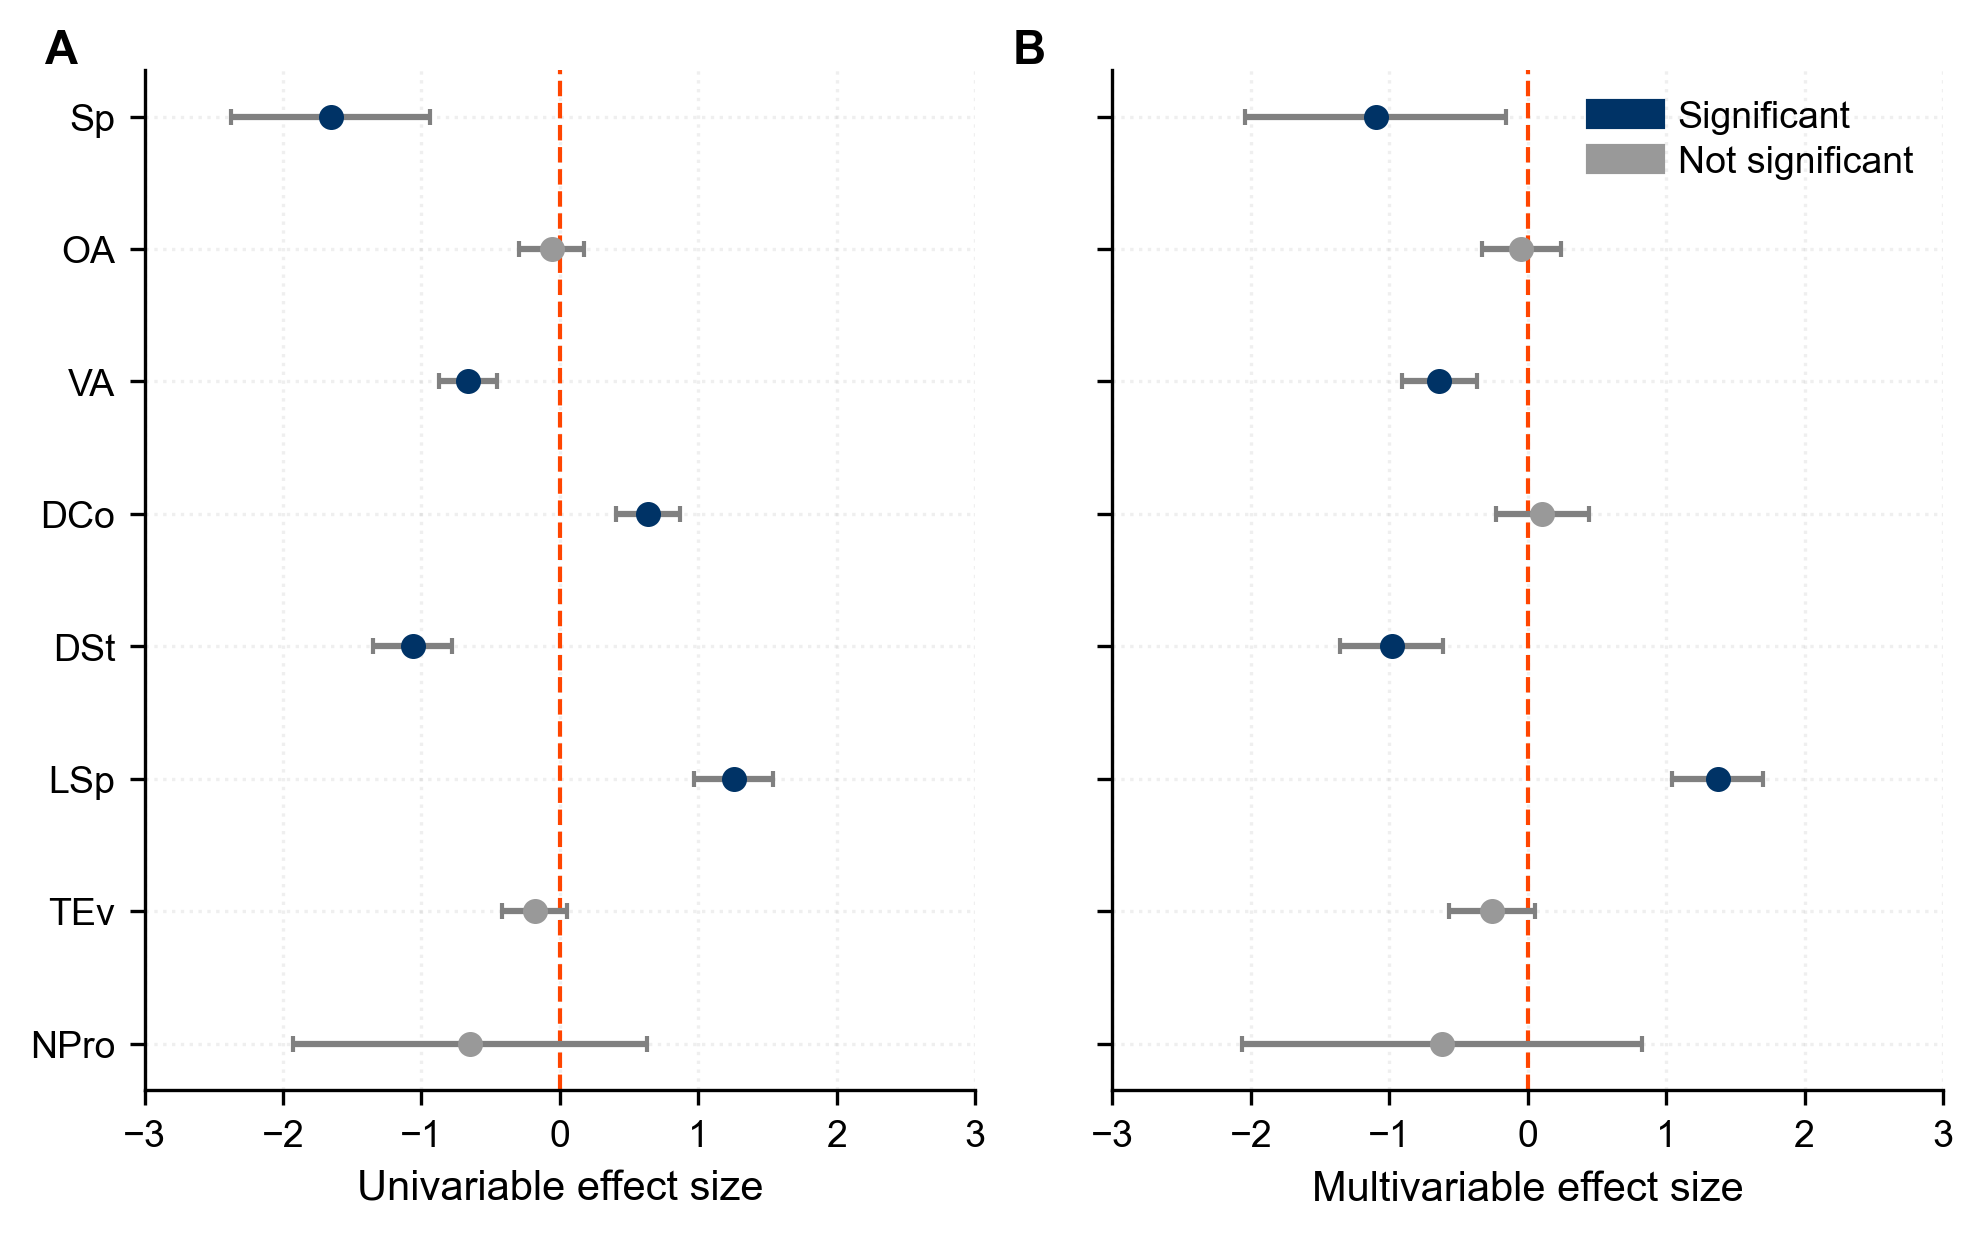

In [302]:
univariable   = pd.read_csv('../outputs/S2_UnivariableNormalized.csv')
multivariable = pd.read_csv('../outputs/S3_MultivariableNormalized_Neighbor_Proximity.csv')

desired_order = ['Sp', 'OA', 'VA', 'DCo', 'DSt', 'LSp', 'TEv', 'NPro']
color_sig    = colors_figures['Deep Sea Blue']    # #003366
color_nonsig = colors_figures['Neutral Gray']     # #999999

def variable_to_label(var):
    if var == '(Intercept)':
        return None
    if isinstance(var, str) and var.startswith('Species'):
        return 'Sp'
    return {
        'Orientation_Angle':    'OA',
        'Viewing_Angle':        'VA',
        'Distance_to_Coral':    'DCo',
        'Distance_to_Stimulus': 'DSt',
        'Loom_Speed':           'LSp',
        'Trial_Event':          'TEv',
        'Neighbor_Proximity':  'NPro',
    }.get(var, None)

def prepare_df(df):
    df = df[df['Variable'] != '(Intercept)'].copy()
    df['Label']   = df['Variable'].apply(variable_to_label)
    df = df.dropna(subset=['Label']).copy()
    for col in ['p_value', 'Std_Error', 'Estimate']:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    df['CI_low']  = df['Estimate'] - 1.96 * df['Std_Error']
    df['CI_high'] = df['Estimate'] + 1.96 * df['Std_Error']
    df['Significant'] = df['p_value'] < 0.05
    rows = []
    for lbl, g in df.groupby('Label', sort=False):
        pick = g.sort_values('p_value').head(1)
        rows.append(pick.iloc[0])
    out = pd.DataFrame(rows)
    out = out[out['Label'].isin(desired_order)].copy()
    out['Label'] = pd.Categorical(out['Label'], categories=desired_order, ordered=True)
    return out.sort_values('Label')

U = prepare_df(univariable)
M = prepare_df(multivariable)

y_map = {lbl: i for i, lbl in enumerate(desired_order[::-1])}
U['y'] = U['Label'].map(y_map)
M['y'] = M['Label'].map(y_map)

fig, ax = plt.subplots(1, 2, figsize=(W_DOUBLE, 4.2), dpi=300, sharey=True, sharex=True)
for a in ax:
    a.axvline(0, color=colors_figures['Sunshine Red'], linestyle='--', linewidth=1)

def draw_panel(axh, df):
    for _, r in df.iterrows():
        axh.errorbar(
            r['Estimate'], r['y'],
            xerr=[[r['Estimate'] - r['CI_low']], [r['CI_high'] - r['Estimate']]],
            fmt='o',
            color=(color_sig if r['Significant'] else color_nonsig),
            ecolor='gray', capsize=2, markersize=5
        )

draw_panel(ax[0], U)
draw_panel(ax[1], M)

yticks = [y_map[lbl] for lbl in desired_order]
ax[0].set_yticks(yticks)
ax[0].set_yticklabels(desired_order)
ax[0].set_xlabel('Univariable effect size')
ax[1].set_xlabel('Multivariable effect size')
ax[0].set_xlim(-3, 3)

legend_elements = [
    Patch(color=color_sig,    label='Significant'),
    Patch(color=color_nonsig, label='Not significant'),
]
ax[1].legend(handles=legend_elements, loc='upper right', frameon=False)

add_panel_label(ax[0], 'A')
add_panel_label(ax[1], 'B')
plt.tight_layout(pad=1.0)
plt.savefig(f'{figures_dir}/FigureS2.pdf', bbox_inches='tight')
plt.savefig(f'{figures_dir}/FigureS2.tiff', dpi=300, format='tiff', bbox_inches='tight',
            pil_kwargs={'compression': 'tiff_lzw'})
plt.savefig(f'{figures_dir}/FigureS2.png', dpi=300, bbox_inches='tight')
plt.show()

## S3 Fig: Response probability by distance to stimulus and viewing angle

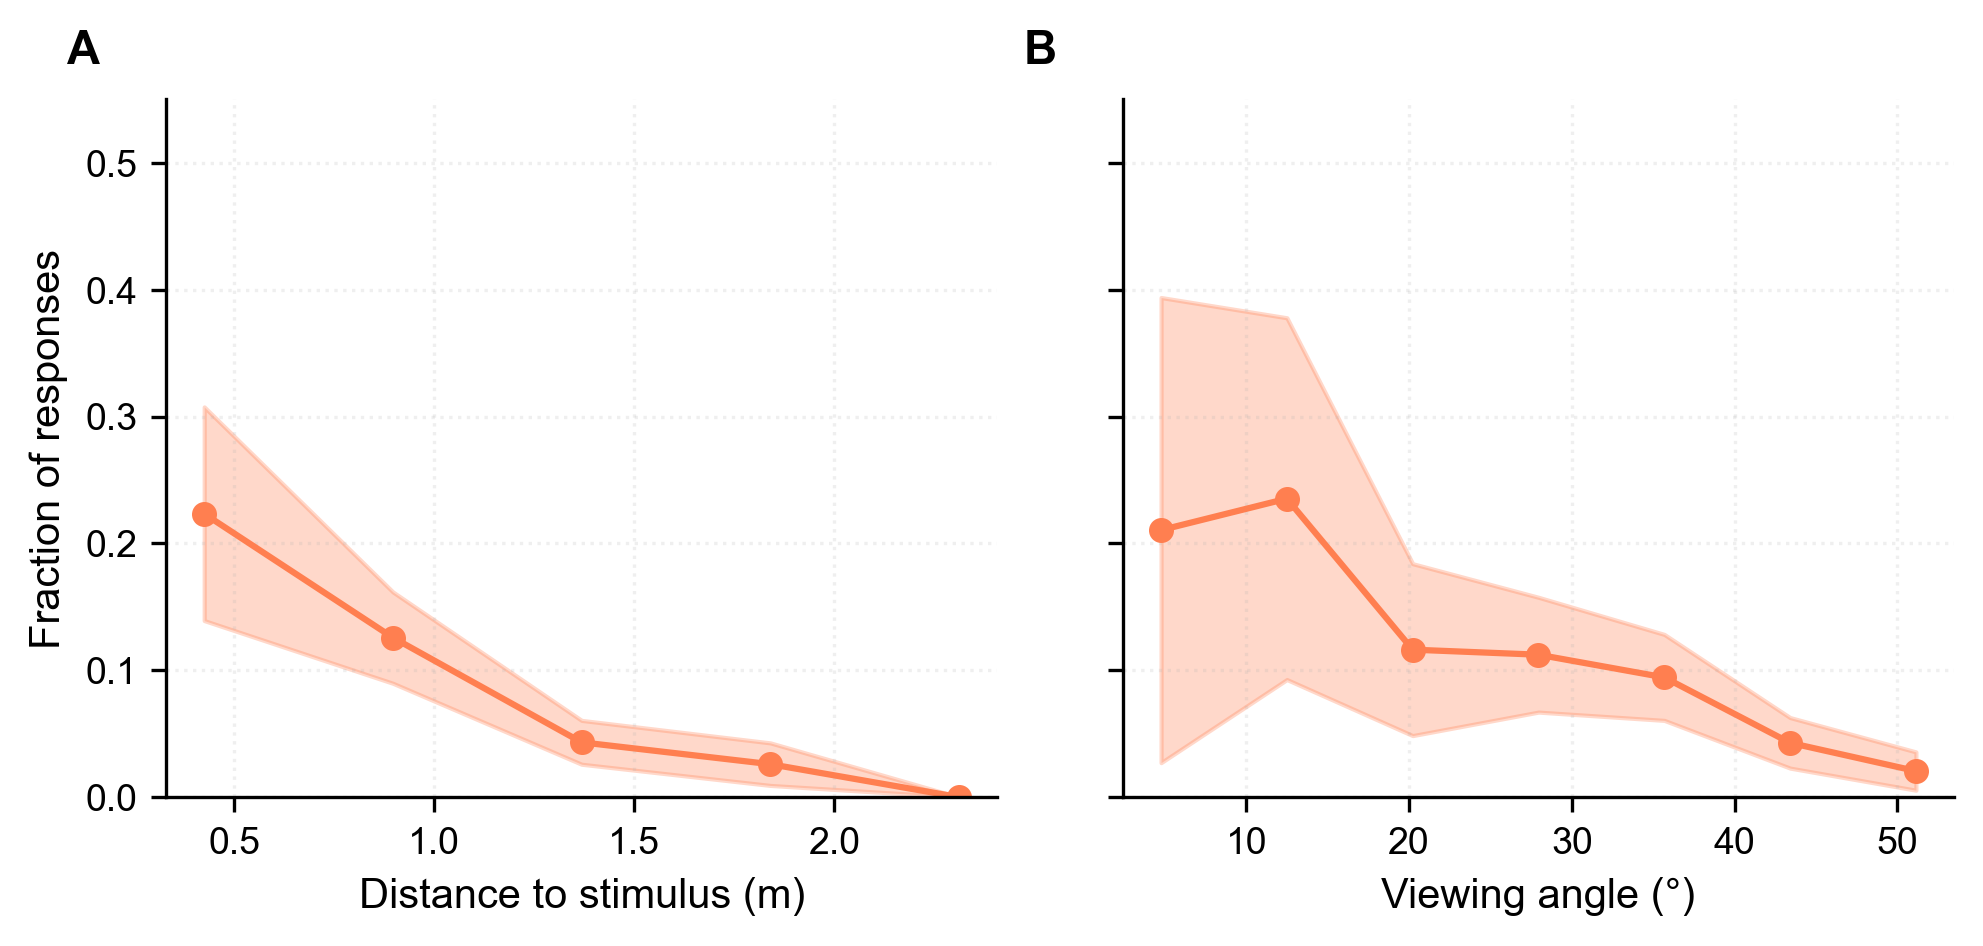

In [306]:
fig, axes = plt.subplots(1, 2, figsize=(W_DOUBLE, 3.25), sharey=True, dpi=300)

# Panel A: distance to stimulus
axes[0].plot(stats_dst['centers'], stats_dst['means'], marker='o',
             color=colors_figures['Coral'])
axes[0].fill_between(stats_dst['centers'], stats_dst['ci_lower'], stats_dst['ci_upper'],
                     color=colors_figures['Coral'], alpha=0.3)
axes[0].set_xlabel('Distance to stimulus (m)')
axes[0].set_ylabel('Fraction of responses')
axes[0].set_ylim(0, 0.55)
add_panel_label(axes[0], 'A', y=1.10)

# Panel B: viewing angle
axes[1].plot(stats_va['centers'], stats_va['means'], marker='o',
             color=colors_figures['Coral'])
axes[1].fill_between(stats_va['centers'], stats_va['ci_lower'], stats_va['ci_upper'],
                     color=colors_figures['Coral'], alpha=0.3)
axes[1].set_xlabel('Viewing angle (°)')
add_panel_label(axes[1], 'B', y=1.10)

plt.tight_layout(pad=1.0)
plt.savefig(f'{figures_dir}/FigureS3.pdf', bbox_inches='tight')
plt.savefig(f'{figures_dir}/FigureS3.tiff', dpi=300, format='tiff', bbox_inches='tight',
            pil_kwargs={'compression': 'tiff_lzw'})
plt.savefig(f'{figures_dir}/FigureS3.png', dpi=300, bbox_inches='tight')
plt.show()

## S4 Fig: Response probability by orientation angle and trial event number

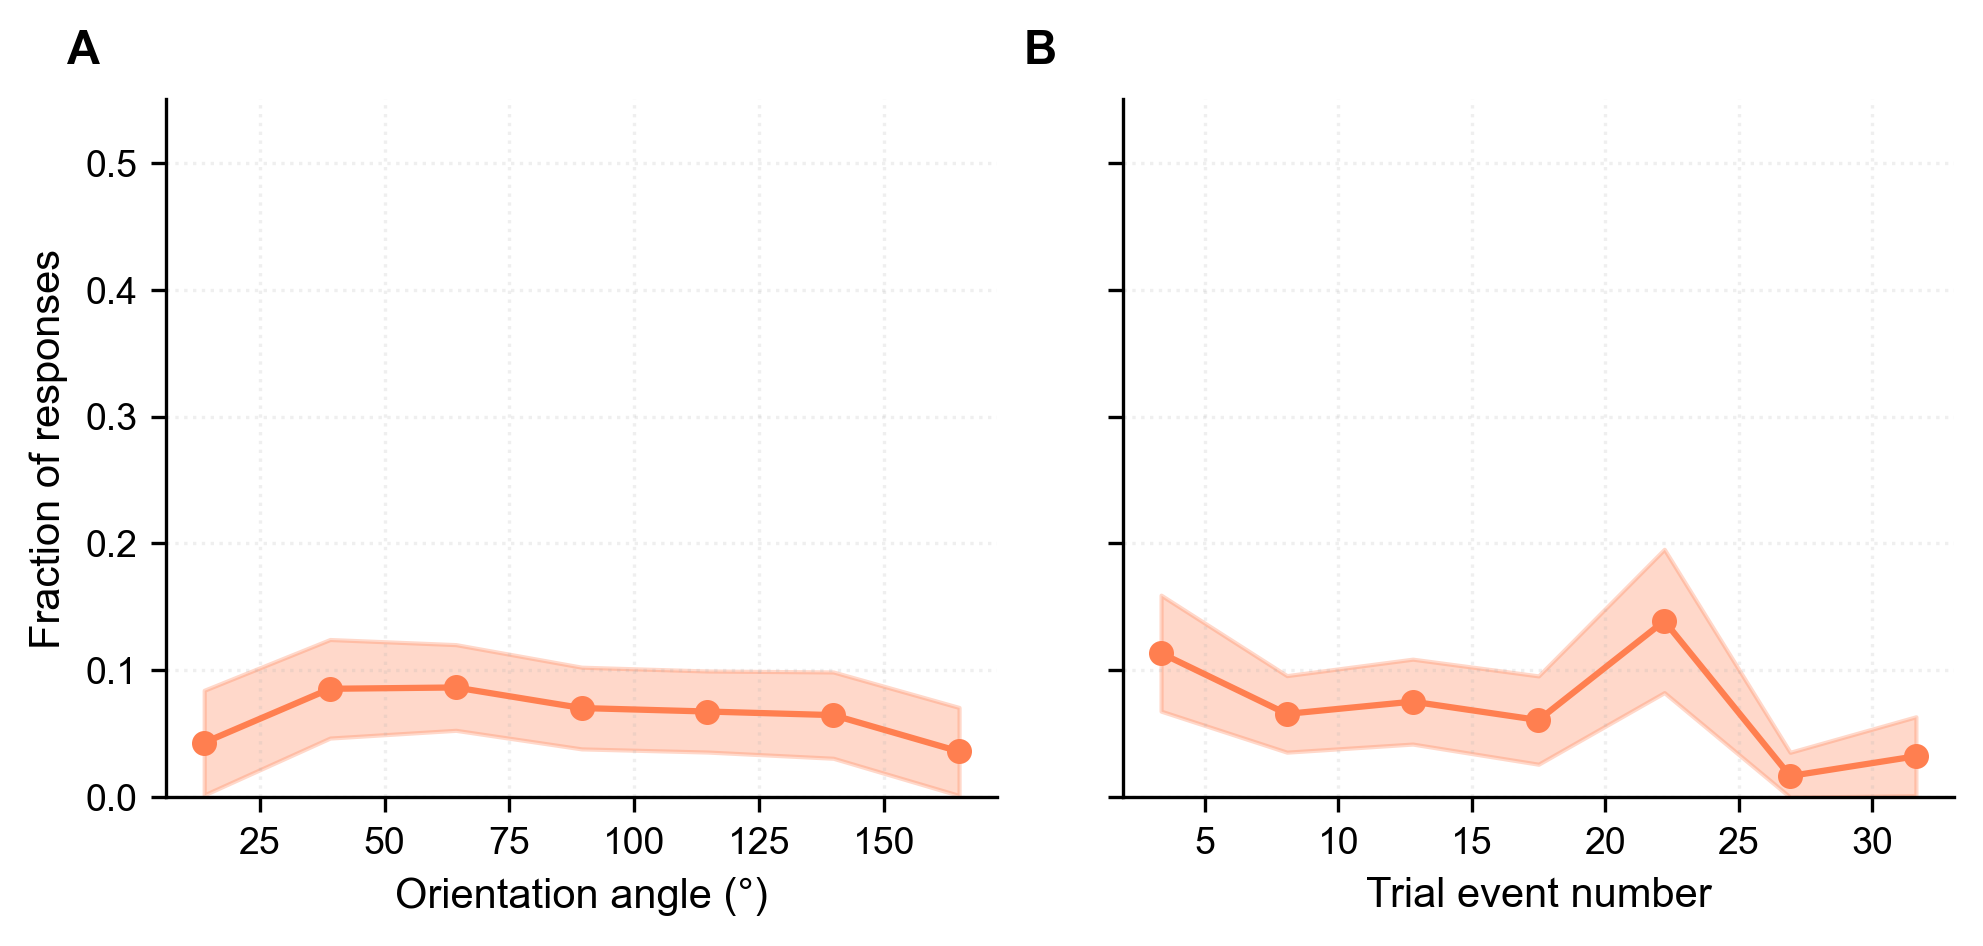

In [307]:
fig, axes = plt.subplots(1, 2, figsize=(W_DOUBLE, 3.25), sharey=True, dpi=300)

# Panel A: orientation angle
axes[0].plot(stats_oa['centers'], stats_oa['means'], marker='o',
             color=colors_figures['Coral'])
axes[0].fill_between(stats_oa['centers'], stats_oa['ci_lower'], stats_oa['ci_upper'],
                     color=colors_figures['Coral'], alpha=0.3)
axes[0].set_xlabel('Orientation angle (°)')
axes[0].set_ylabel('Fraction of responses')
axes[0].set_ylim(0, 0.55)
add_panel_label(axes[0], 'A', y=1.10)

# Panel B: trial event number
axes[1].plot(stats_tev['centers'], stats_tev['means'], marker='o',
             color=colors_figures['Coral'])
axes[1].fill_between(stats_tev['centers'], stats_tev['ci_lower'], stats_tev['ci_upper'],
                     color=colors_figures['Coral'], alpha=0.3)
axes[1].set_xlabel('Trial event number')
add_panel_label(axes[1], 'B', y=1.10)

plt.tight_layout(pad=1.0)
plt.savefig(f'{figures_dir}/FigureS4.pdf', bbox_inches='tight')
plt.savefig(f'{figures_dir}/FigureS4.tiff', dpi=300, format='tiff', bbox_inches='tight',
            pil_kwargs={'compression': 'tiff_lzw'})
plt.savefig(f'{figures_dir}/FigureS4.png', dpi=300, bbox_inches='tight')
plt.show()